In [77]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("uber.csv")

In [78]:
row_count,col = df.shape
row_count,col


(200000, 9)

In [79]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [80]:
df[df['fare_amount']>0]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [81]:
df['key'] = pd.to_datetime(df['key'])

In [82]:
df['day'] = df['key'].dt.day
df['month'] = df['key'].dt.month
df['year'] = df['key'].dt.year
df['hour'] = df['key'].dt.hour

In [83]:
df.drop('Unnamed: 0', axis=1,inplace=True)

1.What is the total number of records in the dataset?

In [84]:
df.shape


(200000, 12)

2.What are the data types of each column?

In [85]:
# df.info()
print("\n2. Data Types:\n", df.dtypes)


2. Data Types:
 key                  datetime64[ns]
fare_amount                 float64
pickup_datetime              object
pickup_longitude            float64
pickup_latitude             float64
dropoff_longitude           float64
dropoff_latitude            float64
passenger_count               int64
day                           int32
month                         int32
year                          int32
hour                          int32
dtype: object


3.How many missing values are present in each column?

In [86]:
missing_values = df.isna().sum()
missing_values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
day                  0
month                0
year                 0
hour                 0
dtype: int64


4.Are there duplicate records in the dataset?

In [87]:
print('Total duplicates in the dataset: \n', df.duplicated().sum())

Total duplicates in the dataset: 
 0


5.What is the date range of the dataset (start → end)?

In [88]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
start = df['pickup_datetime'].min()
end = df['pickup_datetime'].max()
print(f"staring date range -- {start}\nending date range -- {end} ")

staring date range -- 2009-01-01 01:15:22+00:00
ending date range -- 2015-06-30 23:40:39+00:00 


6.How many rides happen per day?

In [89]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
day = df['pickup_datetime'].dt.date
rides_per_day = df.groupby(day)['passenger_count'].size()
# rides_per_day = df.groupby(df['pickup_datetime'].dt.date).size()
# rides_per_day



7.How many rides happen per hour of the day?


In [90]:
rides_per_hour = df['hour'].value_counts().sort_index()
rides_per_hour

hour
0      7844
1      5908
2      4422
3      3256
4      2365
5      1967
6      4139
7      7231
8      9075
9      9339
10     8944
11     9422
12     9924
13    10024
14     9749
15     9614
16     8313
17     9758
18    12072
19    12605
20    11755
21    11446
22    11023
23     9805
Name: count, dtype: int64

8.Which hour has the highest demand?

TypeError: 'str' object is not callable

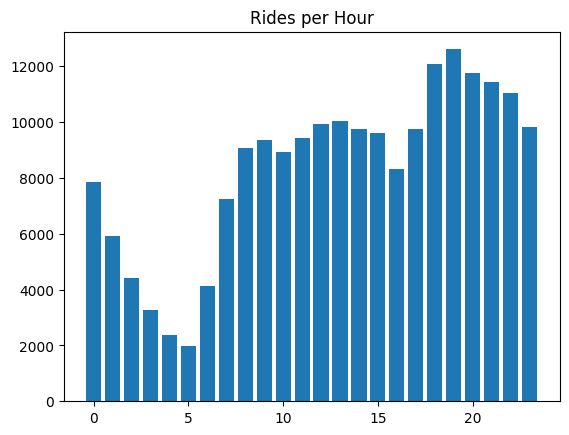

In [91]:
rides_per_hour = df['hour'].value_counts().sort_index()
# rides_per_hour.sort_values(ascending=False)


plt.bar(rides_per_hour.index, rides_per_hour.values)
plt.title("Rides per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.xticks(range(0, 24))


9.Which day of the week has the most rides?

Most Active Day: 18


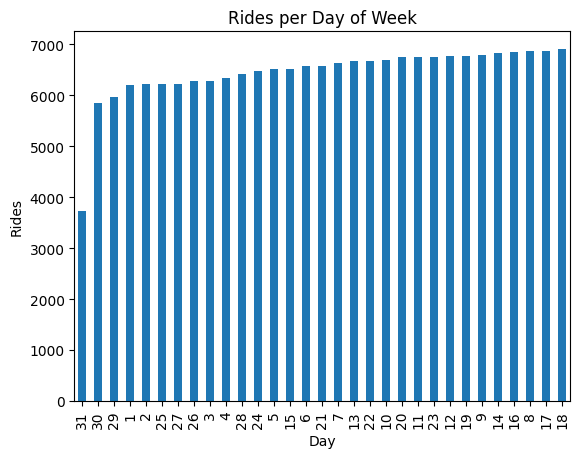

In [ ]:
rides_per_dayname = df['day'].value_counts().sort_values(ascending=True)
print("Most Active Day:", rides_per_dayname.idxmax())
plt.figure()
rides_per_dayname.plot(kind='bar')
plt.title("Rides per Day of Week")
plt.xlabel("Day")
plt.ylabel("Rides")
plt.show()

10.Is there a difference between weekday vs weekend demand?

In [ ]:
df['is_weekend'] = df['pickup_datetime'].dt.weekday >= 5
weekend_counts = df['is_weekend'].value_counts()
print("Weekday vs Weekend:\n", weekend_counts)

Weekday vs Weekend:
 is_weekend
False    143308
True      56692
Name: count, dtype: int64


which weekend has highest fare amount

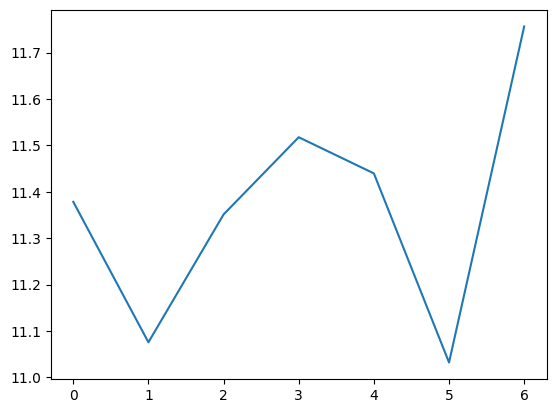

In [93]:
df['weekday'] = df['key'].dt.weekday
graph = df.groupby('weekday')['fare_amount'].mean()
# sns.lineplot(x='fare_amount', y='weekday', data = graph)
plt.plot(graph)



conclusion:
weekday 6 is 11.7 so if we increse riders on weekday 6 we will get more profit

year
2009    10.009096
2010    10.134548
2011    10.403075
2012    11.214300
2013    12.710030
2014    13.017037
2015    12.940731
Name: fare_amount, dtype: float64

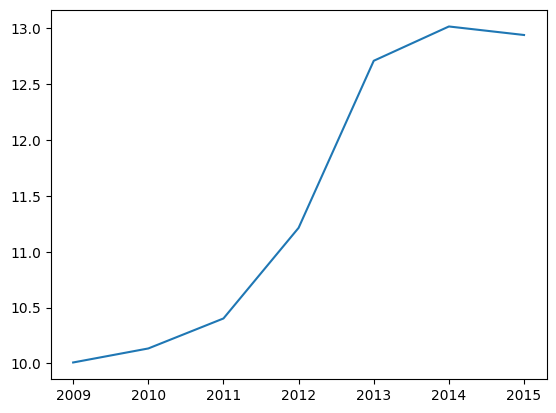

In [111]:
yearVSfare = df.groupby('year')['fare_amount'].mean()
plt.plot(yearVSfare)
yearVSfare


<Axes: xlabel='weekday', ylabel='passenger_count'>

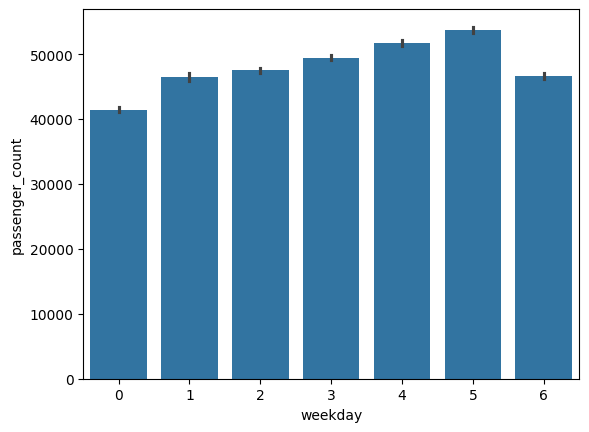

In [110]:
# # weekdayVSpassanger = df.groupby('weekday')['passenger_count'].sum()
# plt.plot(weekdayVSpassanger)
sns.barplot(x=df['weekday'], y=df['passenger_count'],estimator='sum')

<Axes: xlabel='month', ylabel='fare_amount'>

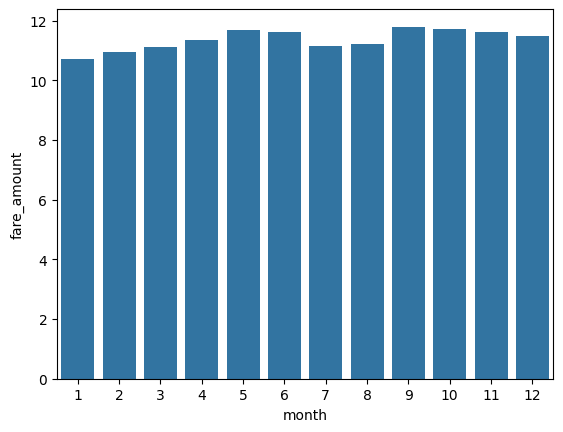

In [117]:
monthss = df.groupby('month')['fare_amount'].mean().sort_values()
sns.barplot(monthss)